# Diseases and Symptoms: Data Exploration

Performs a basic exploration of the dataset. The data file is expected to be present in the same folder as this file under the name `data.csv`.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 160)

DATA_PATH = Path("data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at {DATA_PATH.resolve()}")

In [11]:
# Load column names first, then enforce compact dtypes for symptom columns.
header_only = pd.read_csv(DATA_PATH, nrows=0)
all_columns = header_only.columns.tolist()

target_col = "diseases"
if target_col not in all_columns:
    raise ValueError(f"Expected target column '{target_col}', found: {all_columns[:5]}...")

symptom_cols = [c for c in all_columns if c != target_col]
dtype_map = {c: "uint8" for c in symptom_cols}

df = pd.read_csv(DATA_PATH, dtype=dtype_map)

print(f"Rows: {len(df):,}")
print(f"Unique diseases: {df[target_col].nunique():,}")
print(f"Symptom columns: {len(symptom_cols):,}")
print(f"Memory usage (MB): {df.memory_usage(deep=True).sum() / (1024**2):.2f}")

df.head(3)

Rows: 246,945
Unique diseases: 773
Symptom columns: 377
Memory usage (MB): 104.46


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,...,low urine output,skin on head or neck looks infected,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
# Basic integrity checks
missing_target = df[target_col].isna().sum()
missing_features = int(df[symptom_cols].isna().sum().sum())

# Because features are encoded as binary flags, values outside {0,1} are suspicious.
min_feature_value = int(df[symptom_cols].min().min())
max_feature_value = int(df[symptom_cols].max().max())

print(f"Missing disease labels: {missing_target:,}")
print(f"Missing symptom values: {missing_features:,}")
print(f"Feature value range: [{min_feature_value}, {max_feature_value}]")

Missing disease labels: 0
Missing symptom values: 0
Feature value range: [0, 1]


In [13]:
# Disease occurrence distribution

disease_counts = df[target_col].value_counts()
disease_freq = disease_counts / len(df)

print("Most common diseases:")
display(pd.DataFrame({"count": disease_counts.head(15), "fraction": disease_freq.head(15)}))

print("Least common diseases:")
display(pd.DataFrame({"count": disease_counts.tail(15), "fraction": disease_freq.tail(15)}))

Most common diseases:


,count,fraction
diseases,,
cystitis,1219,0.004936
vulvodynia,1218,0.004932
nose disorder,1218,0.004932
complex regional pain syndrome,1217,0.004928
spondylosis,1216,0.004924
hypoglycemia,1215,0.004920
conjunctivitis due to allergy,1215,0.004920
vaginal cyst,1215,0.004920
esophagitis,1215,0.004920


Least common diseases:


,count,fraction
diseases,,
hypergammaglobulinemia,1,0.000004
open wound of the cheek,1,0.000004
open wound of the knee,1,0.000004
typhoid fever,1,0.000004
open wound due to trauma,1,0.000004
chronic ulcer,1,0.000004
myocarditis,1,0.000004
heat stroke,1,0.000004
high blood pressure,1,0.000004


count    246945.000000
mean          5.332851
std           1.640610
min           1.000000
25%           4.000000
50%           5.000000
75%           6.000000
90%           7.000000
99%           9.000000
max          12.000000
dtype: float64


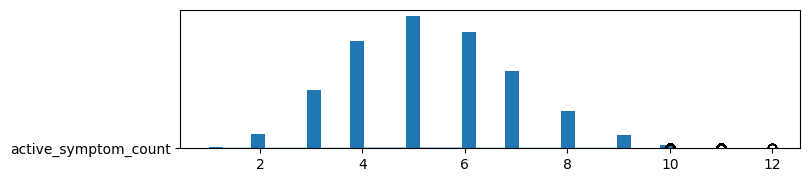

In [14]:
# Symptom density per sample: how many active symptoms in each row?

active_symptom_count = df[symptom_cols].sum(axis=1)

print(active_symptom_count.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

active_symptom_count.hist(bins=40, figsize=(8, 4))
_ = active_symptom_count.rename("active_symptom_count").plot(kind="box", vert=False, figsize=(8, 1.8))

In [15]:
# Most prevalent symptoms across the full dataset

symptom_prevalence = df[symptom_cols].mean().sort_values(ascending=False)
prevalence_table = (symptom_prevalence.head(25) * 100).rename("percent_of_samples").to_frame()
prevalence_table

,percent_of_samples
sharp abdominal pain,13.082670
vomiting,11.287534
headache,10.009921
cough,9.838628
sharp chest pain,9.725242
nausea,9.592014
back pain,8.831521
shortness of breath,8.644030
fever,8.258519
dizziness,6.994270


In [ ]:
# Disease-specific symptom profile helper

def top_symptoms_for_disease(disease_name: str, top_n: int = 15) -> pd.Series:
    subset = df.loc[df[target_col] == disease_name, symptom_cols]
    if subset.empty:
        raise ValueError(f"Disease not found: {disease_name}")
    return subset.mean().sort_values(ascending=False).head(top_n)

# Analyze the most common disease and its symptom profile 
# (as in the symptoms that are most frequently active among samples with that disease).
example_disease = disease_counts.index[0]
print(f"Example disease: {example_disease}")
(top_symptoms_for_disease(example_disease, top_n=12) * 100).rename("percent_with_symptom")

Example disease: cystitis


involuntary urination    52.420016
side pain                51.681706
symptoms of bladder      51.517637
frequent urination       51.189500
suprapubic pain          50.369155
blood in urine           50.287121
lower abdominal pain     50.287121
sharp abdominal pain     49.958983
painful urination        49.384742
back pain                48.154225
retention of urine       48.072190
pelvic pain              47.169811
Name: percent_with_symptom, dtype: float64

In [ ]:
# Example of how we can prepare the data for use with our MLP/models.
# Create feature matrix X and target vector y, encoding categorical labels as integers.

X = df[symptom_cols].to_numpy(dtype=np.uint8)

y_categorical = df[target_col].astype("category")
y = y_categorical.cat.codes.to_numpy(dtype=np.int32)
classes = y_categorical.cat.categories.tolist()
class_to_index = {name: idx for idx, name in enumerate(classes)}

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(classes)}")
print("First 5 classes:", classes[:5])

X shape: (246945, 377)
y shape: (246945,)
Number of classes: 773
First 5 classes: ['abdominal aortic aneurysm', 'abdominal hernia', 'abscess of nose', 'abscess of the lung', 'abscess of the pharynx']


In [ ]:
# Per-disease symptom matrix useful for weightless rule inspection

# Rows: diseases, Columns: symptoms, Values: P(symptom=1 | disease)
mean_symptom_by_disease = df.groupby(target_col, observed=False)[symptom_cols].mean()

print(mean_symptom_by_disease.shape)
mean_symptom_by_disease.head(5) * 100

(773, 377)


,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,...,low urine output,skin on head or neck looks infected,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
diseases,,,,,,,,,,,,,,,,,,,,,,,,,
abdominal aortic aneurysm,0.0,0.0,76.086957,0.0,0.000000,0.0,0.0,0.0,0.0,79.710145,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
abdominal hernia,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
abscess of nose,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
abscess of the lung,0.0,0.0,89.473684,100.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
abscess of the pharynx,0.0,0.0,0.000000,0.0,78.005865,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
